# 02 · ほこナビ walking network and station maps, Ōedo Line

Step 1.3. Logic lives in `importer/analysis/hokonavi.py`. Codes follow 歩行空間ネットワークデータ整備仕様 (MLIT 2024-07) and 階層別屋内地理空間情報データ仕様書 (GSI 2019-03), both linked from the dataset pages.

In [1]:
import pandas as pd
from importer.analysis.hokonavi import *

pd.set_option('display.width', 250, 'display.max_columns', 40, 'display.max_colwidth', 60)
slugs = station_slugs()
stations = {s: load_station(s) for s in slugs}
len(slugs)

12

## 1. Schema

Columns of each layer, taken from 大門.

In [2]:
d = stations['daimon']
for name in ('nodes', 'links', 'floors', 'spaces', 'facilities'):
    g = getattr(d, name)
    print(f'{name:11s} {len(g):4d} rows  geometry={g.geom_type.unique().tolist()}  columns={[c for c in g.columns if c != "geometry"]}')
print('CRS declared in files:', d.nodes.crs, '| all stations:', {s.nodes.crs.to_string() for s in stations.values()})

nodes        340 rows  geometry=['Point']  columns=['FID', 'node_id', 'lat', 'lon', 'floor', 'in_out', 'link1_id', 'link2_id', 'link3_id', 'link4_id', 'link5_id', 'link6_id']
links        378 rows  geometry=['LineString']  columns=['FID', 'link_id', 'start_id', 'end_id', 'distance', 'rank', 'r_method', 'maint_date', 'rt_struct', 'route_type', 'direction', 'width', 'vtcl_slope', 'lev_diff', 'tfc_signal', 'tfc_s_type', 'brail_tile', 'elevator', 'roof']
floors        14 rows  geometry=['Polygon']  columns=['FID', 'id', 'category', 'name', 'ordinal', 'short_name', 'source', 'source_file']
spaces       337 rows  geometry=['Polygon']  columns=['FID', 'id', 'category', 'floor_id', 'name', 'restricted', 'suite', 'nonpublic', 'toll', 'source', 'source_file']
facilities   130 rows  geometry=['Point']  columns=['FID', 'id', 'category', 'floor_id', 'name', 'source', 'source_file']
CRS declared in files: EPSG:6668 | all stations: {'EPSG:6668'}


Attributes that carry the accessibility information, per link: `route_type` (elevator / escalator / stairs / slope), `width`, `vtcl_slope`, `lev_diff` (step height), `elevator` (type), `direction`, `brail_tile`, `roof`. All are **coded ranges, not measurements**; there is no step count.

Code values seen in 大門:

In [3]:
code_counts(d.links)

,field,code,meaning,links
0,route_type,1,no specific type,263
1,route_type,4,elevator,18
2,route_type,5,escalator,25
3,route_type,6,stairs,56
4,route_type,7,slope,7
5,route_type,99,unknown,9
6,rt_struct,5,underground passage,366
7,rt_struct,8,other,3
8,rt_struct,99,unknown,9
9,width,1,<1.0 m,93


## 2. How complete is each attribute?

Share of links with value 99 (unknown), per station. Unknown links are almost always unknown in every field at once (rank `XXX`).

In [4]:
pd.DataFrame({s: unknown_share(st.links) for s, st in stations.items()}).T

,route_type,rt_struct,width,vtcl_slope,lev_diff,elevator,direction
akabanebashi,0.029,0.029,0.029,0.029,0.029,0.029,0.029
aoyama-itchome,0.024,0.024,0.024,0.024,0.024,0.024,0.024
azabu-juban,0.017,0.051,0.013,0.013,0.013,0.013,0.013
daimon,0.024,0.024,0.024,0.024,0.024,0.024,0.024
higashi-shinjuku,0.025,0.033,0.025,0.025,0.025,0.025,0.025
kokuritsu-kyogijo,0.030,0.030,0.033,0.030,0.030,0.030,0.030
roppongi,0.023,0.027,0.023,0.023,0.023,0.023,0.023
shinjuku,0.000,0.000,0.000,0.000,0.000,0.000,0.000
shinjuku-nishiguchi,0.000,0.000,0.000,0.000,0.000,0.000,0.000
tochomae,0.013,0.013,0.013,0.013,0.013,0.013,0.013


In [5]:
u = d.links[d.links.route_type == 99]
print(u[['distance', 'rank', 'r_method', 'width', 'vtcl_slope', 'lev_diff', 'elevator', 'brail_tile', 'roof']].head(4).to_string())
fl = dict(zip(d.nodes.node_id, d.nodes.floor))
print('floors at both ends of the unknown links:', sorted({(fl[r.start_id], fl[r.end_id]) for r in u.itertuples()}))

     distance rank r_method  width  vtcl_slope  lev_diff  elevator  brail_tile  roof
360       6.4  XXX      111     99          99        99        99          99    99
361       2.7  XXX      111     99          99        99        99          99    99
362       4.2  XXX      111     99          99        99        99          99    99
363       6.1  XXX      111     99          99        99        99          99    99
floors at both ends of the unknown links: [(-0.5, 0.0), (0.0, 0.0)]


## 3. Coordinate system and floors

Network nodes carry numeric `floor` (0 = outdoor ground, half floors such as -0.5 are mezzanines). Station-map `Floor` polygons carry `ordinal` and a Japanese name, and spaces and facilities reference a floor polygon by `floor_id`.

In [6]:
rows = []
for s, st in stations.items():
    fl = floor_report(st)
    rows.append({'station': s, 'ordinal dtype': str(st.floors.ordinal.dtype), 'map files': 'per floor' if any('_B' in f or '_1_' in f for f in st.map_files) else 'single', 'floor polygons': len(st.floors), 'network floors': ', '.join(f'{f:g}' for f in fl['network_floors']), 'map floors': ', '.join(f'{f:g}' for f in fl['map_floors']), 'in network, not in map': ', '.join(f'{f:g}' for f in fl['in_network_not_map']) or '-', 'in map, not in network': ', '.join(f'{f:g}' for f in fl['in_map_not_network']) or '-'})
pd.DataFrame(rows)

,station,ordinal dtype,map files,floor polygons,network floors,map floors,"in network, not in map","in map, not in network"
0,akabanebashi,int64,per floor,2,"-2, -1.5, -1, -0.5, 0","-2, -1","-1.5, -0.5, 0",-
1,aoyama-itchome,int64,per floor,7,"-5, -4.5, -4, -3.5, -3, -2, -1.5, -1, -0.5, 0","-5, -4, -3, -1, 1","-4.5, -3.5, -2, -1.5, -0.5, 0",1
2,azabu-juban,int64,per floor,7,"-6, -5.5, -5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0...","-6, -5, -4, -3, -2, -1","-5.5, -4.5, -3.5, -2.5, -1.5, -0.5, 0",-
3,daimon,int64,per floor,14,"-5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0","-5, -4, -3, -2, -1","-4.5, -3.5, -2.5, -1.5, -0.5, 0",-
4,higashi-shinjuku,int64,per floor,4,"-3, -2.5, -2, -1, 0","-3, -2, -1","-2.5, 0",-
5,kokuritsu-kyogijo,float64,per floor,10,"-3, -2.5, -2, -1.5, -1, -0.5, 0","-3, -2, -1, -0.5, 1","-2.5, -1.5, 0",1
6,roppongi,float64,per floor,13,"-7, -6.5, -6, -5.5, -5, -4.5, -4, -3, -2, -1.5, -1, -0.5, 0","-7, -6, -5, -4, -2, -1, -0.5, 1","-6.5, -5.5, -4.5, -3, -1.5, 0",1
7,shinjuku,str,per floor,12,"-6, -4.5, -3, -2.5, -2, -1, -0.5, 0, 1","-6, -5, -3, -2, -1, 1","-4.5, -2.5, -0.5, 0",-5
8,shinjuku-nishiguchi,str,per floor,6,"-4, -3.5, -3, -2, -1.5, -1, -0.7, -0.5, -0.2, 0, 1","-4, -3, -1, -0.5","-3.5, -2, -1.5, -0.7, -0.2, 0, 1",-
9,tochomae,int64,per floor,11,"-3, -2.5, -2, -1.5, -1, -0.5, 0","-3, -2, -1, 1","-2.5, -1.5, -0.5, 0",1


In [7]:
d.floors.groupby(['name', 'ordinal']).size().rename('polygons')

name  ordinal
地下1階  -1         7
地下2階  -2         4
地下3階  -3         1
地下4階  -4         1
地下5階  -5         1
Name: polygons, dtype: int64

## 4. Coverage and cross-checks per station

In [8]:
table = summary_table()
table

,station,nodes,links,floors (network),floors missing from map,elevator links,escalator,stairs,slope,unknown width,unknown slope,unknown step,street to lowest floor step-free,"... strict (<=5 cm, <=8%)",nodes in spaces
0,akabanebashi,124,137,"-2, -1.5, -1, -0.5, 0","-1.5, -0.5, 0",6,8,19,0,0.029,0.029,0.029,True,True,0.56
1,aoyama-itchome,271,295,"-5, -4.5, -4, -3.5, -3, -2, -1.5, -1, -0.5, 0","-4.5, -3.5, -2, -1.5, -0.5, 0",17,12,38,1,0.024,0.024,0.024,True,True,0.64
2,azabu-juban,211,235,"-6, -5.5, -5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0...","-5.5, -4.5, -3.5, -2.5, -1.5, -0.5, 0",12,15,36,5,0.013,0.013,0.013,True,False,0.65
3,daimon,340,378,"-5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0","-4.5, -3.5, -2.5, -1.5, -0.5, 0",18,25,56,7,0.024,0.024,0.024,True,True,0.69
4,higashi-shinjuku,110,120,"-3, -2.5, -2, -1, 0","-2.5, 0",6,6,16,0,0.025,0.025,0.025,True,True,0.80
5,kokuritsu-kyogijo,301,333,"-3, -2.5, -2, -1.5, -1, -0.5, 0","-2.5, -1.5, 0",12,21,53,3,0.033,0.030,0.030,True,True,0.71
6,roppongi,267,298,"-7, -6.5, -6, -5.5, -5, -4.5, -4, -3, -2, -1.5, -1, -0.5, 0","-6.5, -5.5, -4.5, -3, -1.5, 0",9,22,43,8,0.023,0.023,0.023,True,True,0.72
7,shinjuku,233,263,"-6, -4.5, -3, -2.5, -2, -1, -0.5, 0, 1","-4.5, -2.5, -0.5, 0",13,29,22,5,0.000,0.000,0.000,True,True,0.84
8,shinjuku-nishiguchi,225,254,"-4, -3.5, -3, -2, -1.5, -1, -0.7, -0.5, -0.2, 0, 1","-3.5, -2, -1.5, -0.7, -0.2, 0, 1",11,18,37,6,0.000,0.000,0.000,True,False,0.67
9,tochomae,269,307,"-3, -2.5, -2, -1.5, -1, -0.5, 0","-2.5, -1.5, -0.5, 0",11,16,42,2,0.013,0.013,0.013,True,True,0.67


`street to lowest floor step-free`: a ground-level entrance (floor 0, outside or boundary node) reaches a node on the lowest floor without stairs or escalators. `strict` also drops links with a step above 5 cm or a slope above 8%. `nodes in spaces` is the share of network nodes that fall inside a Space polygon of the same floor.

### Links that break the strict check

Slopes steeper than 8% (route_type 7) and steps above 5 cm on non-stairs links.

In [9]:
rows = []
for s, st in stations.items():
    L = st.links
    bad = L[(~L.route_type.isin([5, 6])) & (((L.lev_diff != 99) & (L.lev_diff >= 4)) | L.vtcl_slope.isin([5, 6, 7, 8]))]
    for r in bad.itertuples():
        rows.append({'station': s, 'link': r.link_id[:8], 'route_type': ROUTE_TYPE[r.route_type], 'slope': SLOPE[r.vtcl_slope], 'step': LEV_DIFF[r.lev_diff], 'length m': r.distance})
pd.DataFrame(rows)

,station,link,route_type,slope,step,length m
0,aoyama-itchome,98c1b2cd,slope,8-18% up,0 cm,10.3
1,azabu-juban,6c4cf5df,slope,8-18% up,0 cm,18.6
2,azabu-juban,af6e689c,slope,8-18% up,0 cm,2.9
3,azabu-juban,94c2d0d6,unknown,8-18% down,0 cm,2.6
4,daimon,d5907d9f,slope,8-18% up,0 cm,6.3
5,daimon,10783d7e,slope,8-18% up,0 cm,6.5
6,daimon,ef965642,slope,8-18% up,0 cm,6.4
7,daimon,90d590f5,slope,8-18% down,0 cm,10.9
8,kokuritsu-kyogijo,5bd331c7,slope,8-18% down,0 cm,1.4
9,roppongi,3db53d21,slope,8-18% up,0 cm,6.2


## 5. 大門, floor by floor

Links coloured by type; grey polygons are map spaces. Half floors are drawn on the floor below. Floor 0 has no map polygons.

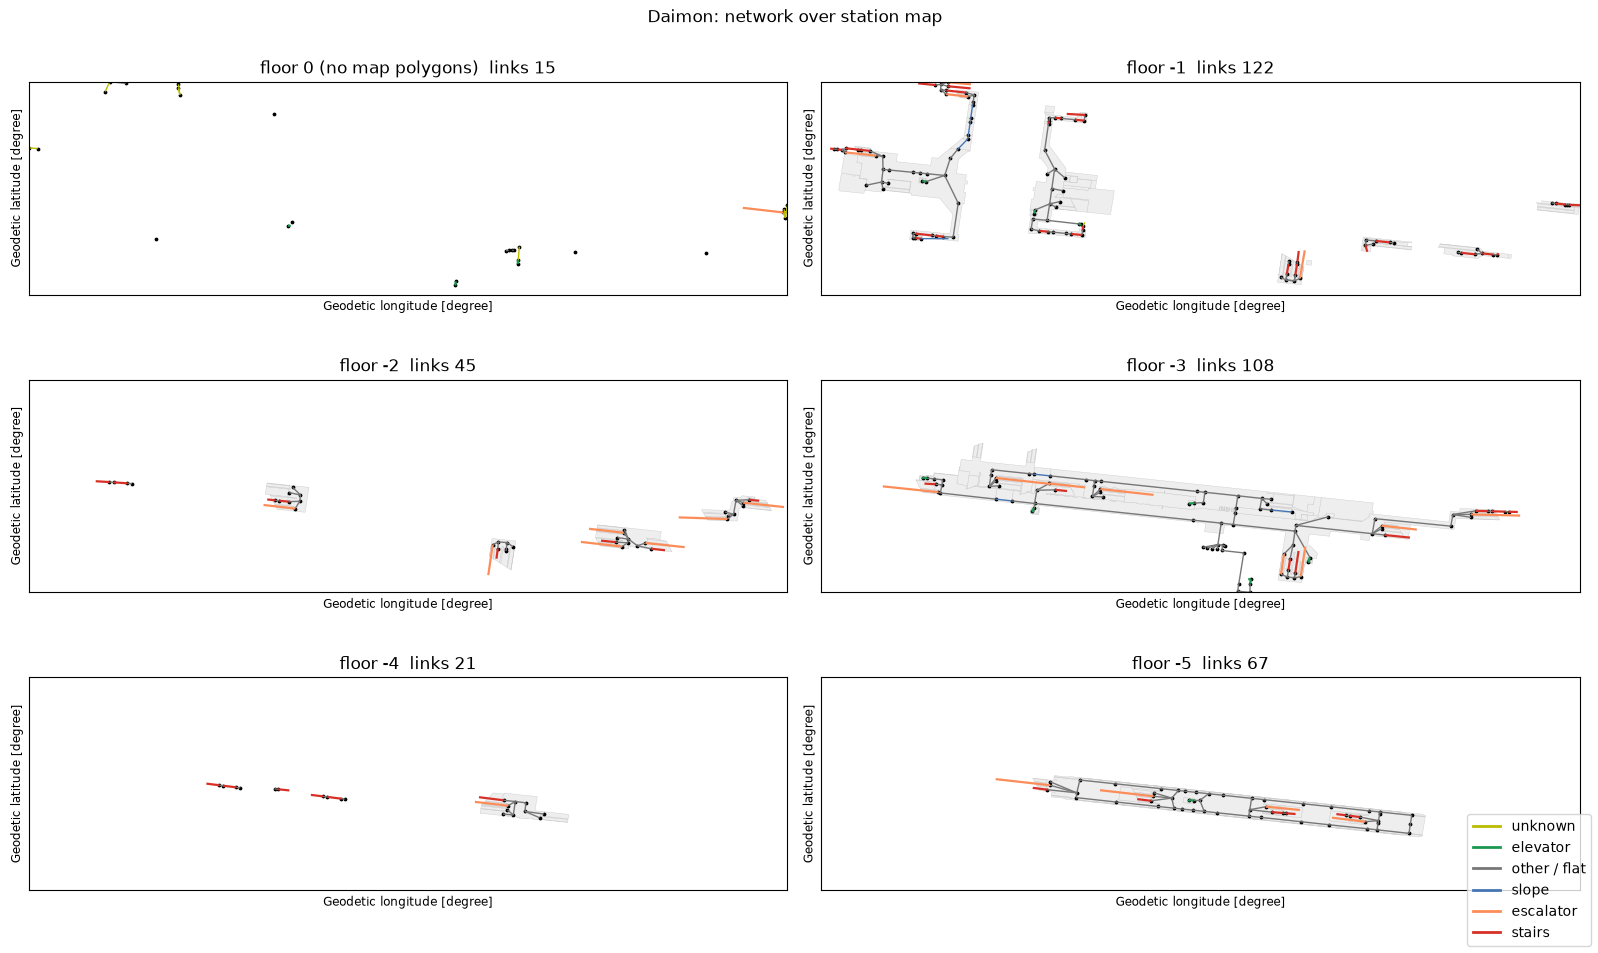

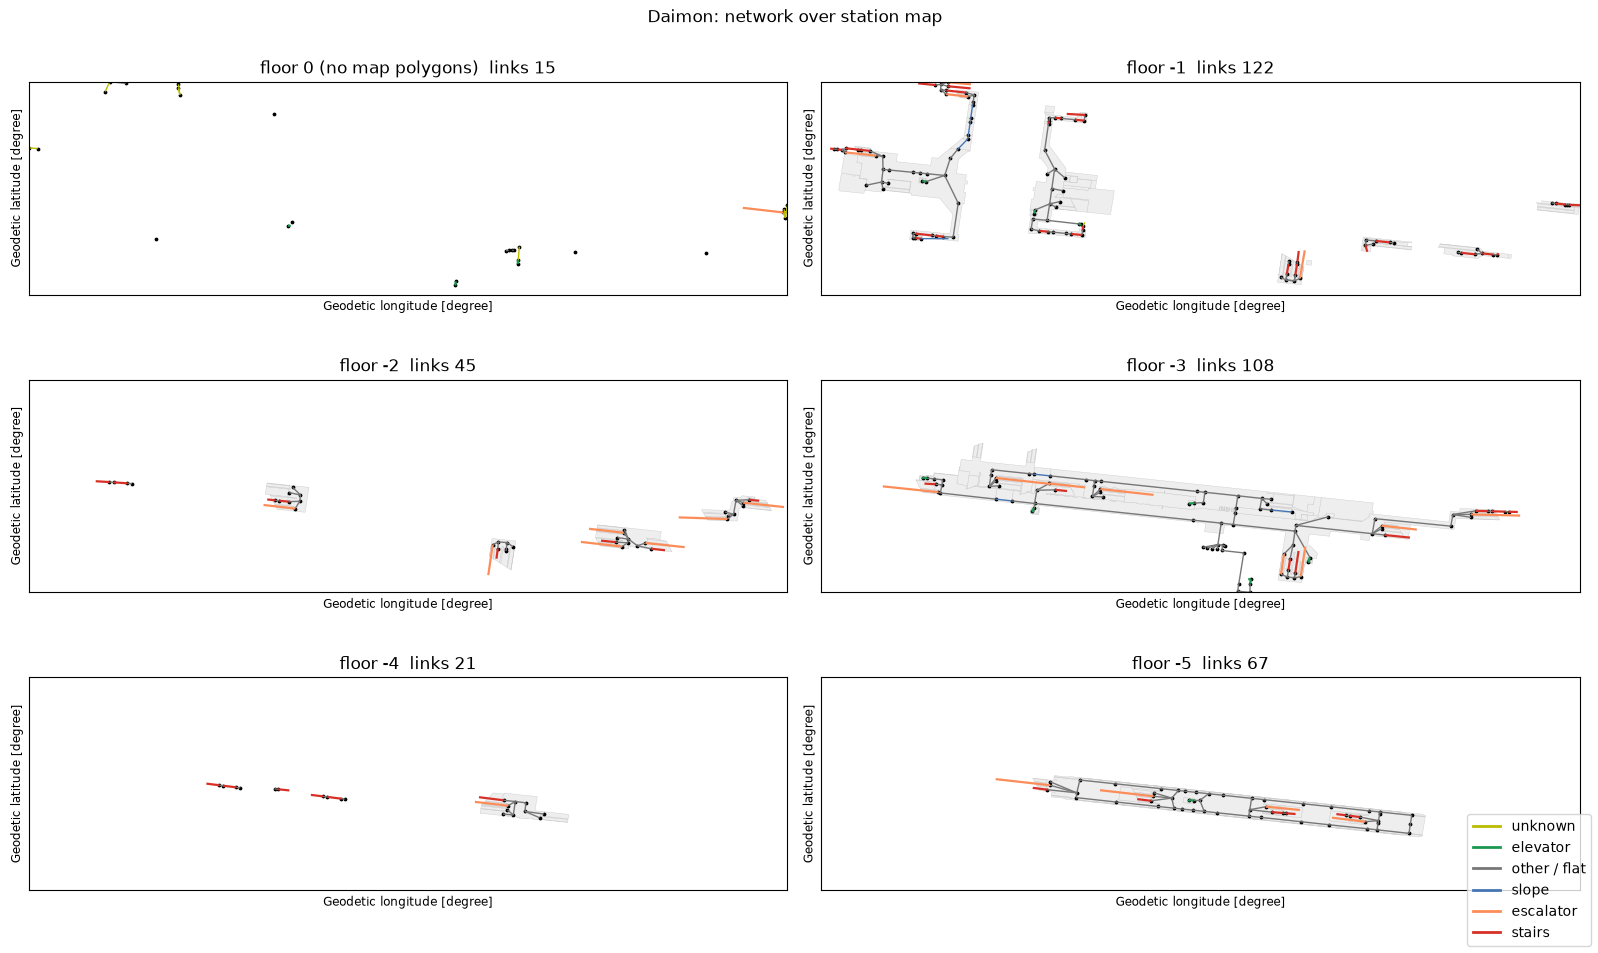

In [10]:
fig = plot_station_floors(stations['daimon'], 'Daimon: network over station map')
fig